# K-Modes Discourse Context Clustering

This notebook clusters the discourse-context labels directly, instead of clustering sentence text.

Selected inputs:
- `Sentence_Type`
- `Emotion`
- `Question_Type`
- `Epistemic_Stance`
- `Listener_Agreement`
- `Position` (renamed from `Particle_Position`)

The goal is to find clusters where `kan` and `ke` naturally concentrate.

## Why K-Modes

K-Modes is a better fit here because these inputs are all categorical. It groups rows by shared discourse-context patterns, which makes the output easier to interpret linguistically than TF-IDF over the raw sentence text.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from kmodes.kmodes import KModes
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

In [10]:
DATA_PATH = Path("../Datasets/ALL_TAGGED_1137.csv")
OUTPUT_DIR = Path(".")
TARGET_COLUMN = "Particle"
SELECTED_COLUMNS = [
    "Sentence_Type",
    "Emotion",
    "Question_Type",
    "Epistemic_Stance",
    "Listener_Agreement",
    "Position",
]

df = pd.read_csv(DATA_PATH)
df = df.rename(columns={"Particle_Position": "Position"})
required_columns = [TARGET_COLUMN] + SELECTED_COLUMNS
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

for column in required_columns:
    df[column] = df[column].fillna("Unknown").astype(str)

print(f"Rows: {len(df):,}")
print("Selected context columns:")
print(SELECTED_COLUMNS)
df[[TARGET_COLUMN] + SELECTED_COLUMNS].head(5)

Rows: 1,137
Selected context columns:
['Sentence_Type', 'Emotion', 'Question_Type', 'Epistemic_Stance', 'Listener_Agreement', 'Position']


,Particle,Sentence_Type,Emotion,Question_Type,Epistemic_Stance,Listener_Agreement,Position
0,ke,Natural,Neutral/Unclear,Rhetorical Interrogative,Certain,Neutral/Unclear,Middle/End
1,kan,Natural,Negative,Rhetorical Interrogative,Certain,Assumed Agreement,Middle/End
2,neutral,Synthesised (removed kan),Negative,Declarative/Statement,Certain,Neutral/Unclear,Unknown
3,neutral,Synthesised (removed kan),Positive,Rhetorical Interrogative,Certain,Assumed Agreement,Unknown
4,kan,Natural,Negative,Rhetorical Interrogative,Certain,Assumed Agreement,Middle/End


In [11]:
label_encoders = {}
reverse_maps = {}
encoded_context = pd.DataFrame(index=df.index)

for column in [TARGET_COLUMN] + SELECTED_COLUMNS:
    encoder = LabelEncoder()
    encoded_context[column] = encoder.fit_transform(df[column])
    label_encoders[column] = encoder
    reverse_maps[column] = {int(code): label for code, label in enumerate(encoder.classes_)}

display(encoded_context.head())
encoding_summary = pd.DataFrame({
    "column": [TARGET_COLUMN] + SELECTED_COLUMNS,
    "num_classes": [len(label_encoders[column].classes_) for column in [TARGET_COLUMN] + SELECTED_COLUMNS],
})
display(encoding_summary)

,Particle,Sentence_Type,Emotion,Question_Type,Epistemic_Stance,Listener_Agreement,Position
0,1,0,1,1,0,2,1
1,0,0,0,1,0,0,1
2,2,2,0,0,0,2,2
3,2,2,2,1,0,0,2
4,0,0,0,1,0,0,1


,column,num_classes
0,Particle,3
1,Sentence_Type,3
2,Emotion,3
3,Question_Type,3
4,Epistemic_Stance,4
5,Listener_Agreement,3
6,Position,3


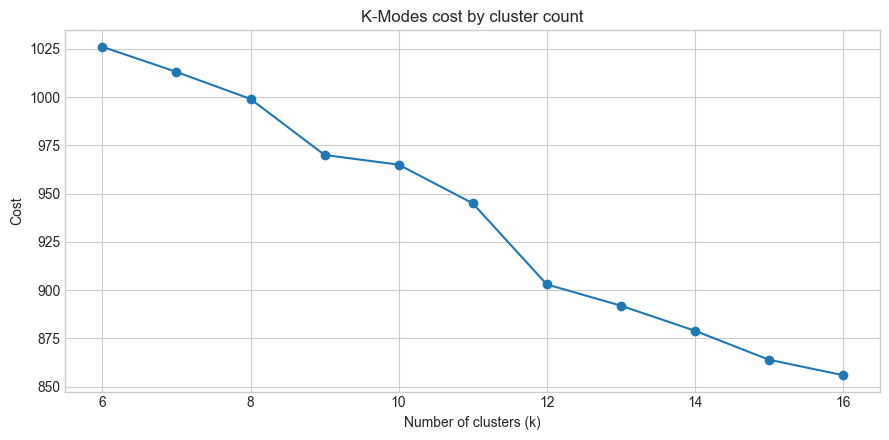

,k,cost
0,6,1026.0
1,7,1013.0
2,8,999.0
3,9,970.0
4,10,965.0
5,11,945.0
6,12,903.0
7,13,892.0
8,14,879.0
9,15,864.0


In [12]:
candidate_k = range(6, 17)
costs = []
X = encoded_context[SELECTED_COLUMNS].to_numpy()

for k in candidate_k:
    model = KModes(n_clusters=k, init="Cao", n_init=5, verbose=0, random_state=42)
    model.fit(X)
    costs.append(model.cost_)

plt.figure(figsize=(9, 4.5))
plt.plot(list(candidate_k), costs, marker="o")
plt.title("K-Modes cost by cluster count")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Cost")
plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(candidate_k), "cost": costs})

In [13]:
CLUSTER_RANGE = range(6, 17)
results_by_k = {}

for n_clusters in CLUSTER_RANGE:
    model = KModes(n_clusters=n_clusters, init="Cao", n_init=5, verbose=0, random_state=23)
    cluster_labels = model.fit_predict(X)

    clustered_df_k = df.copy()
    clustered_df_k["cluster"] = cluster_labels
    results_by_k[n_clusters] = {
        "model": model,
        "clustered_df": clustered_df_k,
    }

print(f"Finished clustering for k values: {list(CLUSTER_RANGE)}")
pd.DataFrame({
    "k": list(results_by_k.keys()),
    "num_clusters_found": [results_by_k[k]["clustered_df"]["cluster"].nunique() for k in results_by_k],
})

Finished clustering for k values: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


,k,num_clusters_found
0,6,6
1,7,7
2,8,8
3,9,9
4,10,10
5,11,11
6,12,12
7,13,13
8,14,14
9,15,15


In [14]:
profiles_by_k = {}

for n_clusters, result in results_by_k.items():
    centroid_codes = pd.DataFrame(result["model"].cluster_centroids_, columns=SELECTED_COLUMNS)
    cluster_profiles = centroid_codes.copy()
    for column in SELECTED_COLUMNS:
        cluster_profiles[column] = cluster_profiles[column].astype(int).map(reverse_maps[column])
    cluster_profiles.index.name = "cluster"

    cluster_sizes = result["clustered_df"]["cluster"].value_counts().sort_index().to_frame(name="size")
    profiles_by_k[n_clusters] = {
        "profiles": cluster_profiles,
        "sizes": cluster_sizes,
    }

display({k: v["sizes"]["size"].sum() for k, v in profiles_by_k.items()})

{6: np.int64(1137),
 7: np.int64(1137),
 8: np.int64(1137),
 9: np.int64(1137),
 10: np.int64(1137),
 11: np.int64(1137),
 12: np.int64(1137),
 13: np.int64(1137),
 14: np.int64(1137),
 15: np.int64(1137),
 16: np.int64(1137)}

In [15]:
particle_results_by_k = {}
particle_overview_rows = []

for n_clusters, result in results_by_k.items():
    clustered_df_k = result["clustered_df"]
    particle_counts = pd.crosstab(clustered_df_k["cluster"], clustered_df_k[TARGET_COLUMN])
    particle_share = particle_counts.div(particle_counts.sum(axis=1), axis=0).fillna(0)
    particle_summary = pd.DataFrame({
        "majority_particle": particle_share.idxmax(axis=1),
        "majority_share": particle_share.max(axis=1),
    })

    kan_clusters = particle_summary.index[particle_summary["majority_particle"] == "kan"].tolist()
    ke_clusters = particle_summary.index[particle_summary["majority_particle"] == "ke"].tolist()

    particle_results_by_k[n_clusters] = {
        "counts": particle_counts,
        "share": particle_share,
        "summary": particle_summary,
        "kan_clusters": kan_clusters,
        "ke_clusters": ke_clusters,
    }

    particle_overview_rows.append({
        "k": n_clusters,
        "kan_majority_clusters": len(kan_clusters),
        "ke_majority_clusters": len(ke_clusters),
        "top_majority_share": float(particle_summary["majority_share"].max()),
    })

particle_overview = pd.DataFrame(particle_overview_rows).sort_values("k")
display(particle_overview)

,k,kan_majority_clusters,ke_majority_clusters,top_majority_share
0,6,2,2,1.0
1,7,3,2,1.0
2,8,4,2,1.0
3,9,4,3,1.0
4,10,4,4,1.0
5,11,4,5,1.0
6,12,5,5,1.0
7,13,5,5,1.0
8,14,6,5,1.0
9,15,6,6,1.0


In [16]:
for n_clusters, result in results_by_k.items():
    clustered_df_k = result["clustered_df"]
    particle_result = particle_results_by_k[n_clusters]

    output_path = OUTPUT_DIR / f"clustered_kmodes_discourse_context_{n_clusters}.csv"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    clustered_df_k.to_csv(output_path, index=False)
    print(f"Saved clustered data to: {output_path}")

    cluster_dir = OUTPUT_DIR / f"clusters_by_id_{n_clusters}"
    cluster_dir.mkdir(parents=True, exist_ok=True)

    for cluster_id in range(n_clusters):
        cluster_slice = clustered_df_k[clustered_df_k["cluster"] == cluster_id]
        cluster_file = cluster_dir / f"cluster_{cluster_id}_{n_clusters}.csv"
        cluster_slice.to_csv(cluster_file, index=False)
        print(f"Saved {len(cluster_slice)} rows to: {cluster_file}")

    print("Clusters most associated with kan:", particle_result["kan_clusters"])
    print("Clusters most associated with ke:", particle_result["ke_clusters"])

    display(particle_result["counts"])
    display(particle_result["share"].round(3))
    display(particle_result["summary"].sort_values("majority_share", ascending=False))

Saved clustered data to: clustered_kmodes_discourse_context_6.csv
Saved 391 rows to: clusters_by_id_6/cluster_0_6.csv
Saved 318 rows to: clusters_by_id_6/cluster_1_6.csv
Saved 111 rows to: clusters_by_id_6/cluster_2_6.csv
Saved 90 rows to: clusters_by_id_6/cluster_3_6.csv
Saved 152 rows to: clusters_by_id_6/cluster_4_6.csv
Saved 75 rows to: clusters_by_id_6/cluster_5_6.csv
Clusters most associated with kan: [0, 3]
Clusters most associated with ke: [2, 4]


Particle,kan,ke,neutral
cluster,,,
0,301,87,3
1,2,1,315
2,0,75,36
3,77,12,1
4,28,124,0
5,0,0,75


Particle,kan,ke,neutral
cluster,,,
0,0.770,0.223,0.008
1,0.006,0.003,0.991
2,0.000,0.676,0.324
3,0.856,0.133,0.011
4,0.184,0.816,0.000
5,0.000,0.000,1.000


,majority_particle,majority_share
cluster,,
5,neutral,1.000000
1,neutral,0.990566
3,kan,0.855556
4,ke,0.815789
0,kan,0.769821
2,ke,0.675676


Saved clustered data to: clustered_kmodes_discourse_context_7.csv
Saved 359 rows to: clusters_by_id_7/cluster_0_7.csv
Saved 319 rows to: clusters_by_id_7/cluster_1_7.csv
Saved 110 rows to: clusters_by_id_7/cluster_2_7.csv
Saved 89 rows to: clusters_by_id_7/cluster_3_7.csv
Saved 155 rows to: clusters_by_id_7/cluster_4_7.csv
Saved 75 rows to: clusters_by_id_7/cluster_5_7.csv
Saved 30 rows to: clusters_by_id_7/cluster_6_7.csv
Clusters most associated with kan: [0, 3, 6]
Clusters most associated with ke: [2, 4]


...

,majority_particle,majority_share
cluster,,
5,neutral,1.000000
10,ke,1.000000
8,ke,1.000000
12,neutral,1.000000
1,neutral,0.996689
6,kan,0.966667
3,kan,0.873563
0,kan,0.825806
2,ke,0.777778


Saved clustered data to: clustered_kmodes_discourse_context_16.csv
Saved 306 rows to: clusters_by_id_16/cluster_0_16.csv
Saved 302 rows to: clusters_by_id_16/cluster_1_16.csv
Saved 45 rows to: clusters_by_id_16/cluster_2_16.csv
Saved 87 rows to: clusters_by_id_16/cluster_3_16.csv
Saved 147 rows to: clusters_by_id_16/cluster_4_16.csv
Saved 75 rows to: clusters_by_id_16/cluster_5_16.csv
Saved 30 rows to: clusters_by_id_16/cluster_6_16.csv
Saved 10 rows to: clusters_by_id_16/cluster_7_16.csv
Saved 17 rows to: clusters_by_id_16/cluster_8_16.csv
Saved 3 rows to: clusters_by_id_16/cluster_9_16.csv
Saved 50 rows to: clusters_by_id_16/cluster_10_16.csv
Saved 23 rows to: clusters_by_id_16/cluster_11_16.csv
Saved 7 rows to: clusters_by_id_16/cluster_12_16.csv
Saved 13 rows to: clusters_by_id_16/cluster_13_16.csv
Saved 18 rows to: clusters_by_id_16/cluster_14_16.csv
Saved 4 rows to: clusters_by_id_16/cluster_15_16.csv
Clusters most associated with kan: [0, 3, 6, 7, 11, 13, 15]
Clusters most assoc

Particle,kan,ke,neutral
cluster,,,
0,253,52,1
1,0,1,301
2,2,35,8
3,76,10,1
4,17,99,31
5,0,0,75
6,29,1,0
7,5,5,0
8,0,17,0


Particle,kan,ke,neutral
cluster,,,
0,0.827,0.170,0.003
1,0.000,0.003,0.997
2,0.044,0.778,0.178
3,0.874,0.115,0.011
4,0.116,0.673,0.211
5,0.000,0.000,1.000
6,0.967,0.033,0.000
7,0.500,0.500,0.000
8,0.000,1.000,0.000


,majority_particle,majority_share
cluster,,
5,neutral,1.000000
12,neutral,1.000000
10,ke,1.000000
8,ke,1.000000
1,neutral,0.996689
6,kan,0.966667
3,kan,0.873563
0,kan,0.826797
2,ke,0.777778
